In [59]:
import pandas as pd
import numpy as np
df=pd.read_pickle(f"../df24.pkl")
y=df['dm']
X=df.drop(columns=['dm'])

In [60]:
X.shape

(4325, 29)

In [61]:
y.shape

(4325,)

In [62]:
y.value_counts()

dm
0    2227
1    1402
2     696
Name: count, dtype: int64

In [63]:
import torch.cuda
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


True
NVIDIA GeForce RTX 4070 SUPER


In [64]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, root_mean_squared_error


# =========================
# 1. Train / Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(y.value_counts())


# =========================
# 2. Preprocessing
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ['age', 'chol', 'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi', 'wk_smk',
            'wk_alc', 'wk_mvpa_work', 'wk_mvpa_play', 'wk_walk', 'wk_sleep', 'glu', 'hba1c',
            'stress', 'wk_break', 'wk_lunch', 'wk_dinner', 'wk_veg1', 'wk_veg2','wk_fruit',
            'edu','income'
            ]
),
            ("cat", OneHotEncoder(handle_unknown="ignore"), ['sex','job',])
    ]
)


# =========================
# 3. Logistic Regression 모델 정의
# =========================
model = LogisticRegression(
    multi_class="multinomial",   # softmax
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)


# =========================
# 4. Pipeline 구성
# =========================
pipe = Pipeline([
    ("preprocess", preprocess),
    ("logreg", model)
])


# =========================
# 5. 모델 학습
# =========================
pipe.fit(X_train, y_train)


# =========================
# 6. 예측
# =========================
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)


# =========================
# 7. 기본 분류 성능
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 score: {f1:.4f}")
# print(f"r2:{r2}, rmse:{rmse}")


dm
0    2227
1    1402
2     696
Name: count, dtype: int64
Accuracy: 0.8740, Precision: 0.8732, Recall: 0.8740, F1 score: 0.8730


c:\Users\cmc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [65]:
y_proba[10:]

array([[9.95139357e-01, 4.85024813e-03, 1.03946260e-05],
       [7.42123865e-01, 2.54692886e-01, 3.18324889e-03],
       [9.72118918e-01, 2.78364113e-02, 4.46704624e-05],
       ...,
       [2.69029439e-78, 2.13021831e-20, 1.00000000e+00],
       [1.18809562e-02, 8.51332539e-01, 1.36786504e-01],
       [9.99820794e-01, 1.79172757e-04, 3.33024476e-08]])

In [66]:
from sklearn.metrics import make_scorer

def ordinal_expected_value(y_proba):
    score = y_proba[:, 1] + 2 * y_proba[:, 2]
    return np.mean(score)

custom_scorer = make_scorer(
    ordinal_expected_value,
    needs_proba=True,
    greater_is_better=True
)


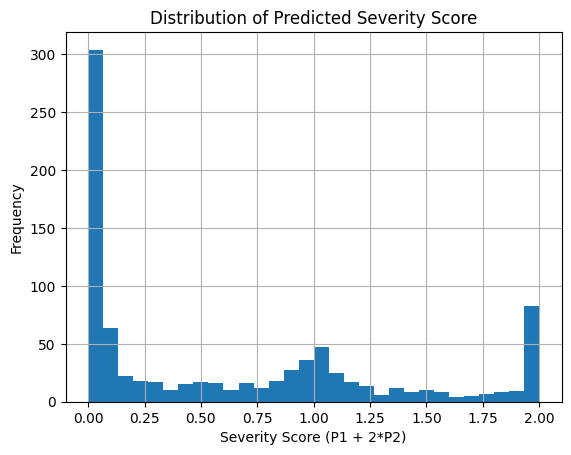

In [67]:
import matplotlib.pyplot as plt

y_score = y_proba[:, 1] + 2 * y_proba[:, 2]
y_score_series = pd.Series(y_score)

y_score_series.hist(bins=30)
plt.xlabel("Severity Score (P1 + 2*P2)")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Severity Score")
plt.show()

In [68]:

# 전처리만 적용
X_test_transformed = pipe.named_steps["preprocess"].transform(X_test)

# 변환된 feature 이름
feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

# DataFrame으로 변환
X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)


In [69]:
logreg_model = pipe.named_steps["logreg"]


In [70]:
import shap

explainer = shap.LinearExplainer(
    logreg_model,
    X_test_transformed
)

shap_values = explainer(X_test_transformed)

severity_shap = (
    shap_values.values[:, :, 1] +
    2 * shap_values.values[:, :, 2]
)



<Axes: >

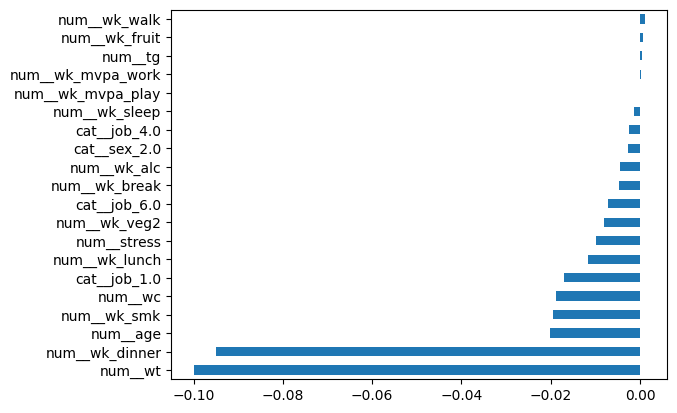

In [71]:
#변수의 기여방향(부호 고려)

mean_abs_severity = np.mean((severity_shap), axis=0)
severity_importance = pd.Series(
    mean_abs_severity,
    index=feature_names
).sort_values(ascending=False)

severity_importance.sort_values(ascending=True).head(20).plot(kind="barh")


<Axes: >

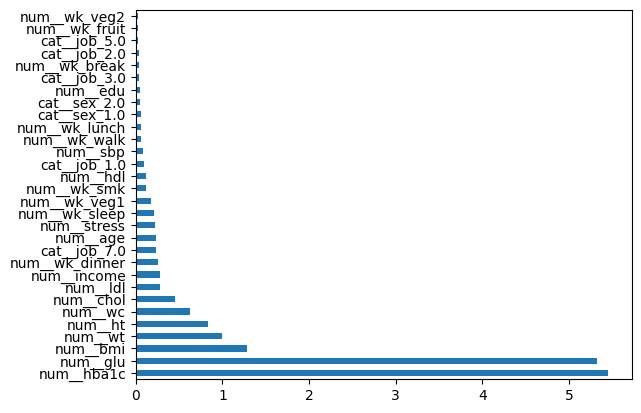

In [75]:
#변수들의 중요도(shap value 절댓값의 평균)

mean_abs_severity = np.mean(np.abs(severity_shap), axis=0)

severity_importance = pd.Series(
    mean_abs_severity,
    index=feature_names
).sort_values(ascending=False)

severity_importance.head(30).plot(kind="barh")


In [81]:
pd.crosstab(df['wk_dinner'], df['dm'])



dm,0,1,2
wk_dinner,,,
0.0,17,13,5
1.5,43,20,19
3.5,190,100,42
6.0,1977,1269,630


In [85]:
# logistic regression 객체 접근
logreg = pipe.named_steps["logreg"]

# 계수 확인
logreg.coef_

# 전처리기 가져오기
preprocess = pipe.named_steps["preprocess"]

# 전처리 후 feature 이름
feature_names = preprocess.get_feature_names_out()

# 계수
coefs = logreg.coef_

coef_df = pd.DataFrame(
    coefs.T,
    index=feature_names,
    columns=[f"class_{c}" for c in logreg.classes_]
)

coef_df


,class_0,class_1,class_2
num__age,0.074490,0.117878,-0.192368
num__chol,0.000887,0.559625,-0.560511
num__hdl,0.126845,-0.119875,-0.006970
num__tg,0.082933,-0.170437,0.087504
num__ldl,0.322007,-0.279528,-0.042479
num__sbp,-0.064158,0.011590,0.052568
num__wt,-0.623367,0.037209,0.586158
num__ht,0.481895,0.044167,-0.526062
num__wc,-0.317920,-0.158416,0.476335
num__bmi,0.748839,0.153177,-0.902016


<Axes: >

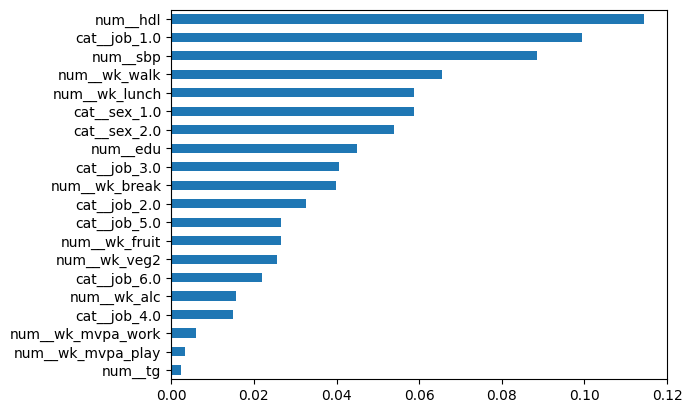

In [74]:
severity_importance.sort_values(ascending=True).head(20).plot(kind="barh")
